## SVM Kernels Implementation

In [91]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [92]:
x = np.linspace(-5, 5, 100)
y = np.sqrt(100-x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [93]:
x1 = np.linspace(-5, 5, 100)
y1 = np.sqrt(25-x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

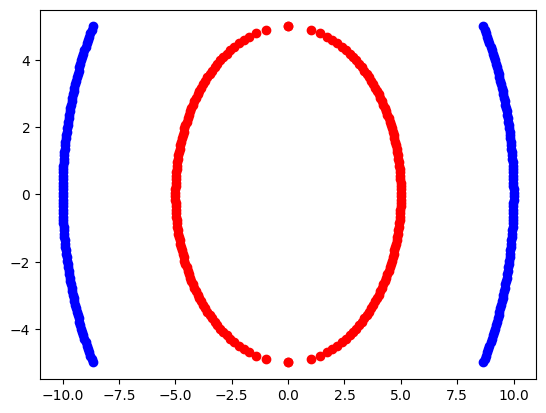

In [94]:
plt.scatter(y, x, color='blue', label='Class 1')
plt.scatter(y1, x1, color='red', label='Class 2')

In [95]:
df1 = pd.DataFrame(np.vstack([y,x]).T , columns=['X1', 'X2'])
df1['Y']=0
df2 = pd.DataFrame(np.vstack([y1,x1]).T , columns=['X1', 'X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [96]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [97]:
X = df.drop('Y', axis=1)
y = df['Y']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Polynomial kernel

In [99]:
df['X1_squared'] = df['X1']**2
df['X2_squared'] = df['X2']**2
df['X1_X2'] = df['X1'] * df['X2']
df.head()

,X1,X2,Y,X1_squared,X2_squared,X1_X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [100]:
from plotly.express import scatter_3d
scatter_3d(df, x='X1_squared', y='X2_squared', z='X1_X2', color='Y')

In [101]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with Linear Kernel: {accuracy:.2f}")

Accuracy with Linear Kernel: 0.47


In [102]:
model = SVC(kernel='poly', degree=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with Polynomial Kernel: {accuracy:.2f}")

Accuracy with Polynomial Kernel: 1.00


In [103]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with RBF Kernel: {accuracy:.2f}")

Accuracy with RBF Kernel: 1.00


In [104]:
model = SVC(kernel='sigmoid')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with Sigmoid Kernel: {accuracy:.2f}")

Accuracy with Sigmoid Kernel: 0.55
